In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm
from sklearn.gaussian_process.kernels import RationalQuadratic, Matern, WhiteKernel, DotProduct, ConstantKernel
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.optimize import differential_evolution, minimize, differential_evolution
from scipy.stats import norm
from scipy.spatial.distance import cdist


In [9]:
# Load all data
folder = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_4')

def load_data():
    file_path_inputs =  folder / folder2 / rf"initial_inputs.npy"
    file_path_outputs = folder / folder2 / rf"initial_outputs.npy"
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    print('Initial data :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.412848, 0.414685, 0.355282, 0.42625], dtype=np.float64)
    Y_new_point = np.array([0.6849177036717049], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 1 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.454583, 0.431596, 0.203237, 0.441412], dtype=np.float64)
    Y_new_point = np.array([-3.2404168784000897], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 2 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.383902, 0.421285, 0.420518, 0.438417], dtype=np.float64)
    Y_new_point = np.array([0.4269079981369086], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 3 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.393953, 0.414733, 0.411142, 0.431984], dtype=np.float64)
    Y_new_point = np.array([0.5191124533860045], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 4 :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.413756, 0.479427, 0.383486, 0.425102], dtype=np.float64)
    Y_new_point = np.array([-0.916455668932517], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 5 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.000000, 0.000000, 1.000000, 1.000000], dtype=np.float64)
    Y_new_point = np.array([-40.348489596712525], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 6 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.404812, 0.333996, 0.423985, 0.441067], dtype=np.float64)
    Y_new_point = np.array([0.13790421556807475], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 7 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.390862, 0.379857, 0.416377, 0.433213], dtype=np.float64)
    Y_new_point = np.array([0.3799145967865454], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 8 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.389404, 0.379514, 0.421602, 0.434926], dtype=np.float64)
    Y_new_point = np.array([0.36194168725820974], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 9 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.299423, 0.398437, 0.481251, 0.476135], dtype=np.float64)
    Y_new_point = np.array([-3.5934228543054405], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 10 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.477669, 0.284911, 0.394503, 0.456496], dtype=np.float64)
    Y_new_point = np.array([-2.8493249912542917], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 11 :','X.shape', X.shape, 'Y.shape', Y.shape)

    # next week new values go here !!!!
  
    return X,Y

X,Y = load_data()
bounds = [(0, 1)] * 4

Initial data : X.shape (30, 4) Y.shape (30,)
Added week 1 : X.shape (31, 4) Y.shape (31,)
Added week 2 : X.shape (32, 4) Y.shape (32,)
Added week 3 : X.shape (33, 4) Y.shape (33,)
Added week 4 : X.shape (34, 4) Y.shape (34,)
Added week 5 : X.shape (35, 4) Y.shape (35,)
Added week 6 : X.shape (36, 4) Y.shape (36,)
Added week 7 : X.shape (37, 4) Y.shape (37,)
Added week 8 : X.shape (38, 4) Y.shape (38,)
Added week 9 : X.shape (39, 4) Y.shape (39,)
Added week 10 : X.shape (40, 4) Y.shape (40,)
Added week 11 : X.shape (41, 4) Y.shape (41,)


In [10]:
# print('X.shape', X.shape)
# print('X col1 min',np.min(X[:, 0]), 'max',np.max(X[:, 0]))
# print('X col2 min',np.min(X[:, 1]), 'max',np.max(X[:, 1]))
# print('Y.shape', Y.shape)
print("Min Y =",min(Y),"Max Y =",max(Y))

Min Y = -40.348489596712525 Max Y = 0.6849177036717049


In [11]:
print("X",X)
print("Y",Y)

X [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.1703473

## 27 Apr - v3 - The "Stabilization" Run

In [13]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.optimize import fmin_l_bfgs_b, differential_evolution

# 2. ADAPTIVE OPTIMIZER
def l_bfgs_v2(obj_func, initial_theta, bounds):
    # Higher maxiter to handle the 'stretch' of the new coordinates
    res = fmin_l_bfgs_b(obj_func, initial_theta, bounds=bounds, maxiter=700)
    return res[0], res[1]

# 3. KERNEL DESIGN
# Using a slightly larger length_scale_bounds to allow the model to connect 
# the '0.4 island' with these new '0.17 probes'.
kernel = ConstantKernel(1.0) * RationalQuadratic(
    length_scale=1.2, 
    alpha=0.1, 
    length_scale_bounds=(0.05, 10.0)
) + WhiteKernel(noise_level=1e-3)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=2e-3, # Increased noise tolerance slightly for more robust fits
    normalize_y=True, 
    n_restarts_optimizer=70, 
    optimizer=l_bfgs_v2
)
model.fit(X, Y)

# 4. SEARCHING FOR THE RIDGE
def target_ucb(x, kappa=4.0):
    center = np.array([0.4, 0.4, 0.4, 0.4])
    # Maintain the 'No-Fly Zone' to ensure we don't slip back to 0.4
    if np.linalg.norm(x - center) < 0.25:
        return 1000.0
    
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + kappa * s[0])

res = differential_evolution(target_ucb, [(0, 1)] * 4, popsize=80)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 5. REPORTING
print(f"STAKEHOLDER TARGET: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"PREDICTED MEAN: {pred_y[0]:.6f}")
print(f"POTENTIAL CEILING: {pred_y[0] + 4.0 * pred_s[0]:.6f}")

STAKEHOLDER TARGET: 0.385960-0.429803-0.167515-0.314176
PREDICTED MEAN: -3.756139
POTENTIAL CEILING: 0.820492


## 27 Apr - v2 - "Mapping the Dead Zones"

In [12]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.optimize import fmin_l_bfgs_b, differential_evolution

# 2. MODEL RE-CALIBRATION
def opt_wrapper(obj, theta, bounds):
    res = fmin_l_bfgs_b(obj, theta, bounds=bounds, maxiter=600) # Increased iterations for deeper learning
    return res[0], res[1]

# We use a slightly more flexible kernel (alpha=0.05) to allow for sharper peaks
kernel = ConstantKernel(1.0) * RationalQuadratic(alpha=0.05, length_scale=1.0) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=70, optimizer=opt_wrapper)
model.fit(X, Y)

# 3. THE "EXPANSIVE" SEARCH
def expansive_ucb(x, kappa=4.5): # Ultra-high exploration
    center = np.array([0.4, 0.4, 0.4, 0.4])
    dist = np.linalg.norm(x - center)
    
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    score = m[0] + kappa * s[0]
    
    # We maintain the 0.25 exclusion zone to prevent "relapsing" to the center
    if dist < 0.25:
        return 2000.0 
    return -score

res = differential_evolution(expansive_ucb, [(0, 1)] * 4, popsize=80)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. DISCOVERY LOG
print(f"NEXT TARGET: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"EXPECTED MEAN: {pred_y[0]:.6f}")
print(f"EXPLORATION POTENTIAL: {pred_y[0] + 4.5 * pred_s[0]:.6f}")

NEXT TARGET: 0.390889-0.428819-0.170728-0.304887
EXPECTED MEAN: -3.793323
EXPLORATION POTENTIAL: 1.593586


## 27 Apr - v1 - "Expanding the Search Perimeter"

In [5]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.optimize import fmin_l_bfgs_b, differential_evolution

# 2. MODEL OPTIMIZATION
def opt_wrapper(obj, theta, bounds):
    res = fmin_l_bfgs_b(obj, theta, bounds=bounds, maxiter=500)
    return res[0], res[1]

kernel = ConstantKernel(1.0) * RationalQuadratic(alpha=0.1, length_scale=1.0) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=60, optimizer=opt_wrapper)
model.fit(X, Y)

# 3. ACQUISITION: AGGRESSIVE DISCOVERY
def wide_scan_ucb(x, kappa=4.0): # High Kappa for max exploration
    center = np.array([0.4, 0.4, 0.4, 0.4])
    dist = np.linalg.norm(x - center)
    
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    score = m[0] + kappa * s[0]
    
    # Increase Penalty radius to 0.25 to force a significant jump
    if dist < 0.25:
        return 1000.0 
    return -score

res = differential_evolution(wide_scan_ucb, [(0, 1)] * 4, popsize=80)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. REPORT
print("--- DISCOVERY REPORT ---")
print(f"Jump Distance: {np.linalg.norm(best_x - np.array([0.4, 0.4, 0.4, 0.4])):.4f}")
print(f"Confidence Level: {1.0 - model.kernel_.k2.noise_level:.4f}")

print("\n--- NEXT SUBMISSION ---")
print(f"Coordinates: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Mean: {pred_y[0]:.6f}")
print(f"Potential Peak (UCB): {pred_y[0] + 4.0 * pred_s[0]:.6f}")

--- DISCOVERY REPORT ---
Jump Distance: 0.2500
Confidence Level: 0.9942

--- NEXT SUBMISSION ---
Coordinates: 0.382995-0.432476-0.161581-0.334314
Predicted Mean: -3.690666
Potential Peak (UCB): 0.999096


## 23 Apr - v2 - The "Pure Discovery" Code

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.optimize import fmin_l_bfgs_b, differential_evolution
# 2. MODEL 
def opt_wrapper(obj, theta, bounds):
    res = fmin_l_bfgs_b(obj, theta, bounds=bounds, maxiter=500)
    return res[0], res[1]

kernel = ConstantKernel(1.0) * RationalQuadratic(alpha=0.1, length_scale=1.0) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=50, optimizer=opt_wrapper)
model.fit(X, Y)

# 3. SEARCH
def ucb_search(x, kappa=3.5):
    center = np.array([0.4, 0.4, 0.4, 0.4])
    if np.linalg.norm(x - center) < 0.15: return 1000.0
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + kappa * s[0])

res = differential_evolution(ucb_search, [(0, 1)] * 4, popsize=80)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. REPORT
print(f"NEXT TARGET: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"PREDICTED Y: {pred_y[0]:.6f}")
print(f"UPPER BOUND: {pred_y[0] + 3.5 * pred_s[0]:.6f}")

NEXT TARGET: 0.477669-0.284911-0.394503-0.456496
PREDICTED Y: -0.745022
UPPER BOUND: 2.200301


## 23 Apr - v1 - The High-Value Probe

In [5]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.optimize import fmin_l_bfgs_b, differential_evolution

# 2. MODEL TUNING
def opt_wrapper(obj, theta, bounds):
    res = fmin_l_bfgs_b(obj, theta, bounds=bounds, maxiter=400)
    return res[0], res[1]

kernel = ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=0.1, length_scale_bounds=(0.1, 5.0)) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=40, optimizer=opt_wrapper)
model.fit(X, Y)

# 3. ACQUISITION: DIVERSITY-DRIVEN SEARCH
def diversification_ucb(x, kappa=3.5): # Increased kappa to prioritize new areas
    center = np.array([0.4, 0.4, 0.4, 0.4])
    dist = np.linalg.norm(x - center)
    
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    score = m[0] + kappa * s[0]
    
    # Penalty Wall: Still forcing the model to stay outside the "stagnant" 0.4 zone
    if dist < 0.15:
        return 1000.0 
    return -score

res = differential_evolution(diversification_ucb, [(0, 1)] * 4, popsize=80)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. DASHBOARD
print("--- STRATEGIC DASHBOARD ---")
print(f"Exclusion distance from 0.4 center: {np.linalg.norm(best_x - np.array([0.4, 0.4, 0.4, 0.4])):.4f}")
print(f"Current Model Confidence (Noise): {model.kernel_.k2.noise_level:.6f}")

print("\n--- NEXT SUBMISSION ---")
print(f"Coordinates: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Mean: {pred_y[0]:.6f}")
print(f"Potential Peak (UCB): {pred_y[0] + 3.5 * pred_s[0]:.6f}")

--- STRATEGIC DASHBOARD ---
Exclusion distance from 0.4 center: 0.1501
Current Model Confidence (Noise): 0.003732

--- NEXT SUBMISSION ---
Coordinates: 0.475233-0.282922-0.395756-0.456046
Predicted Mean: -0.747775
Potential Peak (UCB): 2.199502


## 10 April - v2 - The "Manual Jump"

In [8]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.stats import norm
from scipy.optimize import differential_evolution, fmin_l_bfgs_b

# 1. DATASET
X = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437], [0.8893564, 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242], [0.34696206, 0.0062504, 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761], [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425], [0.74670224, 0.7570915, 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229], [0.6260706, 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991], [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656], [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651, 0.93917791, 0.37619173], [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248], [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348], [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701, 0.33541983, 0.99948256], [0.17034731, 0.75695908, 0.27652049, 0.5312315],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683], [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669, 0.453192, 0.10588734], [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778], [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001], [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.412848, 0.414685, 0.355282, 0.42625], [0.454583, 0.431596, 0.203237, 0.441412],
    [0.383902, 0.421285, 0.420518, 0.438417], [0.393953, 0.414733, 0.411142, 0.431984],
    [0.413756, 0.479427, 0.383486, 0.425102], [0.0, 0.0, 1.0, 1.0],
    [0.404812, 0.333996, 0.423985, 0.441067], [0.390862, 0.379857, 0.416377, 0.433213],
    [0.389404, 0.379514, 0.421602, 0.434926]
])

Y = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511, -10.06963343,
    -15.48708254, -12.68168498, -16.02639977, -17.04923465, -12.74176599,
    -27.31639636, -13.52764887, -16.6791152, -16.50715856, -17.81799934,
    -26.56182083, -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914, -11.56574199, -26.85778644, -7.96677535, -6.70208925,
    -32.62566022, -19.98949793, -4.02554228, -13.12278233, -23.1394284,
    0.6849177, -3.24041688, 0.426908, 0.51911245, -0.91645567,
    -40.3484896, 0.13790422, 0.3799146, 0.36194169
])

# 2. MODEL SETUP
def optimizer_wrapper(obj_func, initial_theta, bounds):
    res = fmin_l_bfgs_b(obj_func, initial_theta, bounds=bounds, maxiter=250)
    return res[0], res[1]

kernel = ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=0.2, length_scale_bounds=(0.1, 5.0)) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=25, optimizer=optimizer_wrapper)
model.fit(X, Y)

# 3. SPATIAL EXCLUSION STRATEGY
# This function penalizes points too close to the existing "0.4 cluster"
def forced_exploration_ucb(x, kappa=3.0):
    # Calculate distance to our current "plateau" center [0.4, 0.4, 0.4, 0.4]
    center = np.array([0.4, 0.4, 0.4, 0.4])
    dist = np.linalg.norm(x - center)
    
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    score = m[0] + kappa * s[0]
    
    # Apply a "Penalty Wall": If we are within 0.15 of the center, crush the score
    if dist < 0.15:
        return 100.0 # High value because differential_evolution minimizes
    return -score

res = differential_evolution(forced_exploration_ucb, [(0, 1)] * 4, popsize=60)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. REPORT
print("=== FORCED EXPLORATION REPORT ===")
print(f"Distance from Plateau Center: {np.linalg.norm(best_x - np.array([0.4, 0.4, 0.4, 0.4])):.4f}")

print("\n=== NEXT SUBMISSION ===")
print(f"Coordinates: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y: {pred_y[0]:.6f}")
print(f"Uncertainty (σ): {pred_s[0]:.6f}")

=== FORCED EXPLORATION REPORT ===
Distance from Plateau Center: 0.1501

=== NEXT SUBMISSION ===
Coordinates: 0.299423-0.398437-0.481251-0.476135
Predicted Y: -0.591267
Uncertainty (σ): 0.483419


## 10 April - v1 - Uncertainty-Weighted Acquisition function

In [7]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.stats import norm
from scipy.optimize import differential_evolution, fmin_l_bfgs_b

# 1. COMPLETE DATASET (39 points)
X = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437], [0.8893564, 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242], [0.34696206, 0.0062504, 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761], [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425], [0.74670224, 0.7570915, 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229], [0.6260706, 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991], [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656], [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651, 0.93917791, 0.37619173], [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248], [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348], [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701, 0.33541983, 0.99948256], [0.17034731, 0.75695908, 0.27652049, 0.5312315],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683], [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669, 0.453192, 0.10588734], [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778], [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001], [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.412848, 0.414685, 0.355282, 0.42625], [0.454583, 0.431596, 0.203237, 0.441412],
    [0.383902, 0.421285, 0.420518, 0.438417], [0.393953, 0.414733, 0.411142, 0.431984],
    [0.413756, 0.479427, 0.383486, 0.425102], [0.0, 0.0, 1.0, 1.0],
    [0.404812, 0.333996, 0.423985, 0.441067], [0.390862, 0.379857, 0.416377, 0.433213],
    [0.389404, 0.379514, 0.421602, 0.434926]
])

Y = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511, -10.06963343,
    -15.48708254, -12.68168498, -16.02639977, -17.04923465, -12.74176599,
    -27.31639636, -13.52764887, -16.6791152, -16.50715856, -17.81799934,
    -26.56182083, -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914, -11.56574199, -26.85778644, -7.96677535, -6.70208925,
    -32.62566022, -19.98949793, -4.02554228, -13.12278233, -23.1394284,
    0.6849177, -3.24041688, 0.426908, 0.51911245, -0.91645567,
    -40.3484896, 0.13790422, 0.3799146, 0.36194169
])

# 2. UPDATED WRAPPER AND MODEL CONFIG
# Fixed: Returns only (theta, func_value) as expected by fit()
def optimizer_with_more_iters(obj_func, initial_theta, bounds):
    res = fmin_l_bfgs_b(obj_func, initial_theta, bounds=bounds, maxiter=250)
    return res[0], res[1]

kernel = ConstantKernel(1.0) * RationalQuadratic(
    length_scale=1.0, 
    alpha=0.2, 
    length_scale_bounds=(0.1, 3.0)
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=5e-4, # Increased for better optimization stability
    normalize_y=True, 
    n_restarts_optimizer=25,
    optimizer=optimizer_with_more_iters
)

model.fit(X, Y)

# 3. STRATEGY: PIVOT TO EXPLORATION (UCB)
# High kappa rewards searching where uncertainty is high.
def exploration_ucb(x, kappa=3.0):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + kappa * s[0])

res = differential_evolution(exploration_ucb, [(0, 1)] * 4, popsize=50)
best_x = res.x
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 4. REPORT
print("=== EXPLORATION REPORT ===")
print(f"Final Kernel: {model.kernel_}")
print(f"Kappa: 3.0 (High Exploration Mode)")

print("\n=== NEXT SUBMISSION ===")
print(f"Coordinates: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y (Mean): {pred_y[0]:.6f}")
print(f"Uncertainty (σ):    {pred_s[0]:.6f}")
print(f"Upper Bound Value:  {pred_y[0] + 3.0 * pred_s[0]:.6f}")

=== EXPLORATION REPORT ===
Final Kernel: 4.26**2 * RationalQuadratic(alpha=0.0983, length_scale=2.42) + WhiteKernel(noise_level=0.000707)
Kappa: 3.0 (High Exploration Mode)

=== NEXT SUBMISSION ===
Coordinates: 0.383558-0.375121-0.427051-0.436948
Predicted Y (Mean): 0.373977
Uncertainty (σ):    0.315368
Upper Bound Value:  1.320082


## 2 April - v3

In [10]:
# 2. OPTIMIZED MODEL CONFIGURATION
# We give the optimizer more iterations to converge.
# We also slightly increase alpha (noise tolerance) for stable fitting.
kernel = ConstantKernel(1.0) * RationalQuadratic(
    length_scale=0.5, 
    alpha=0.1, 
    length_scale_bounds=(0.01, 2.0) # Increased bounds to prevent "muzzling"
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=1e-4, # Stable noise floor
    normalize_y=True, 
    n_restarts_optimizer=25, # Sufficient restarts to avoid local minima
    optimizer='fmin_l_bfgs_b'
)

# Fitting with a higher iteration count to suppress the L-BFGS warnings
model.fit(X, Y)

# 3. ACQUISITION FUNCTION (EI)
def refined_ei(x, xi=0.01):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    if s[0] <= 0: return 0.0
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

res = differential_evolution(refined_ei, [(0, 1)] * 4, popsize=50)
best_x = res.x

# 4. PREDICTION
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 5. OUTPUT
print("=== MODEL STATUS ===")
print(f"Final Kernel: {model.kernel_}")
print(f"Noise Level:  {model.kernel_.k2.noise_level:.6f}")

print("\n=== NEXT SUBMISSION ===")
print(f"Coordinates: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y: {pred_y[0]:.6f}")
print(f"Std Dev (σ): {pred_s[0]:.6f}")

C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 17 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepro

=== MODEL STATUS ===
Final Kernel: 3.59**2 * RationalQuadratic(alpha=0.15, length_scale=2) + WhiteKernel(noise_level=0.00133)
Noise Level:  0.001327

=== NEXT SUBMISSION ===
Coordinates: 0.389404-0.379514-0.421602-0.434926
Predicted Y: 0.379116
Std Dev (σ): 0.405958


## 2 April - v2

In [9]:
# 2. ROBUST MODEL SETUP
# We use sample weights to prioritize positive outcomes.
sample_alphas = np.ones(len(Y)) * 1e-6
sample_alphas[Y < 0] = 1e-4

# Using RationalQuadratic to capture both global trends and local "bumps".
kernel = ConstantKernel(1.0) * RationalQuadratic(
    length_scale=0.5, 
    alpha=0.1, 
    length_scale_bounds=(0.01, 1.5)
) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2))

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=sample_alphas, 
    normalize_y=True, 
    n_restarts_optimizer=50
)
model.fit(X, Y)

# 3. OPTIMIZATION FOR NEXT CANDIDATE
def refined_ei(x, xi=0.01):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    if s[0] <= 0: return 0.0
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

res = differential_evolution(refined_ei, [(0, 1)] * 4, popsize=60)
best_x = res.x

# 4. PREDICTION FOR CANDIDATE
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# 5. CONSULTANT REPORT
print("=== MODEL DATA ===")
learned_k = model.kernel_
print(f"Learned Kernel: {learned_k}")
print(f"Learned Noise:  {learned_k.k2.noise_level:.6f}")

print("\n=== PREDICTION ===")
print(f"Next Submission: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y:     {pred_y[0]:.6f}")
print(f"Uncertainty (σ): {pred_s[0]:.6f}")

C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepro

=== MODEL DATA ===
Learned Kernel: 2.72**2 * RationalQuadratic(alpha=0.287, length_scale=1.5) + WhiteKernel(noise_level=0.00138)
Learned Noise:  0.001380

=== PREDICTION ===
Next Submission: 0.390230-0.380790-0.421319-0.435686
Predicted Y:     0.387581
Uncertainty (σ): 0.410999


## 2 April - v1 - The "Sharp Peak" Model

In [5]:
# 1. THE "SHARP" KERNEL
# nu=1.5 produces a less smooth surface than 2.5, better for detecting local optima.
# We cap the length_scale at 1.0 to prevent the "blob" effect.
kernel = ConstantKernel(1.0) * Matern(
    length_scale=[0.5]*4, 
    length_scale_bounds=(0.05, 1.0), 
    nu=1.5 
) + WhiteKernel(noise_level=1e-3)

# 2. WEIGHTED FIT
# We trust our positive results significantly more than the noisy negatives.
sample_alphas = np.ones(len(Y)) * 1e-6
sample_alphas[Y < 0] = 1e-3 

model = GaussianProcessRegressor(kernel=kernel, alpha=sample_alphas, normalize_y=True, n_restarts_optimizer=50)
model.fit(X, Y)

# 3. ACQUISITION (Expected Improvement)
def refined_ei(x, xi=0.02): # Increased xi slightly to encourage jumping to a new peak
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    if s[0] <= 0: return 0.0
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

res = differential_evolution(refined_ei, [(0, 1)] * 4, popsize=60)
best_x = res.x

# 4. PREDICTION
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

print("=== MODEL DATA ===")
print(f"Learned Length Scales: {np.round(model.kernel_.k1.k2.length_scale, 4)}")
print(f"Learned Noise: {model.kernel_.k2.noise_level:.6f}")

print("\n=== PREDICTION ===")
print(f"Next Submission: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y:     {pred_y[0]:.6f}")
print(f"Uncertainty (σ): {pred_s[0]:.6f}")

C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave

=== MODEL DATA ===
Learned Length Scales: [1. 1. 1. 1.]
Learned Noise: 0.000010

=== PREDICTION ===
Next Submission: 0.422537-0.387869-0.372194-0.479230
Predicted Y:     0.688589
Uncertainty (σ): 0.597818


## 26 March - v1 - Weighted Gaussian Process

In [6]:
# 1. ENHANCED MODEL FIT
sample_alphas = np.ones(len(Y)) * 1e-6
sample_alphas[Y < 0] = 1e-4  # Down-weight negative results (assume higher noise)

kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + WhiteKernel(noise_level=1e-3)
model = GaussianProcessRegressor(kernel=kernel, alpha=sample_alphas, normalize_y=True, n_restarts_optimizer=50)
model.fit(X, Y)

# 2. EXTRACT MODEL INTERNALS
# Extracting the learned parameters from the fitted kernel
learned_kernel = model.kernel_
params = learned_kernel.get_params()
l_scales = learned_kernel.k1.k2.length_scale
noise_lvl = learned_kernel.k2.noise_level

# 3. OPTIMIZATION (Refined EI)
def refined_ei(x, xi=0.01):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    if s[0] <= 0: return 0.0
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

res = differential_evolution(refined_ei, [(0, 1)] * 4, popsize=50)
best_x = res.x

# 4. PREDICTION FOR CANDIDATE
pred_y, pred_s = model.predict(best_x.reshape(1, -1), return_std=True)

# --- CONSULTANT REPORT ---
print("=== MODEL DATA ===")
print(f"Learned Length Scales: {np.round(l_scales, 4)}")
print(f"Learned Noise Level:   {noise_lvl:.6f}")
print(f"Model Amplitude:       {learned_kernel.k1.k1.constant_value:.4f}")

print("\n=== PREDICTION ===")
print(f"Next Submission: {'-'.join(f'{v:.6f}' for v in best_x)}")
print(f"Predicted Y:     {pred_y[0]:.6f}")
print(f"Uncertainty (σ): {pred_s[0]:.6f}")

=== MODEL DATA ===
Learned Length Scales: [1.7941 1.747  1.6603 1.7219]
Learned Noise Level:   0.001552
Model Amplitude:       10.4922

=== PREDICTION ===
Next Submission: 0.390862-0.379857-0.416377-0.433213
Predicted Y:     0.396176
Uncertainty (σ): 0.438492


## New Code 19 March - The "Return to Quality"

In [7]:

# 1. MODEL RE-CALIBRATION
# The large negative Y will cause the Matern kernel to shrink its length scales
kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + \
         WhiteKernel(noise_level=1e-3)

model = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
model.fit(X, Y)

def robust_ei(x):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    
    # Standard EI
    z = (m[0] - f_max - 0.01) / s[0]
    ei = (m[0] - f_max - 0.01) * norm.cdf(z) + s[0] * norm.pdf(z)
    
    # DISTANCE PENALTY: Prevent the model from picking a point too close 
    # to the noisy -0.9 or the failed -40.3
    dists = cdist(x.reshape(1, -1), X)
    min_dist = np.min(dists)
    
    # If the point is within 0.1 of any previous point, heavily penalize it
    penalty = 1.0 if min_dist > 0.1 else (min_dist / 0.1)
    
    return -(ei * penalty)

res = differential_evolution(robust_ei, [(0, 1)] * 4, popsize=40)
best_x = res.x

print(f"Submit: {'-'.join(f'{val:.6f}' for val in best_x)}")
print(f"model.kernel: {model.kernel_}")

# 1. Get the prediction (mean) and the uncertainty (std deviation)
# best_x is the output from your differential_evolution or robust_ei search
pred_mean, pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

# 2. Display the results
print(f"--- Model Prediction for Next Submission ---")
print(f"Candidate: {best_x}")
print(f"Predicted Y (Expected Value): {pred_mean[0]:.6f}")
print(f"Confidence (Standard Deviation): {pred_std[0]:.6f}")

# 3. Calculate 'Upper Bound' (Best Case Scenario)
# This is often what UCB uses to justify exploration
upper_bound = pred_mean[0] + (1.96 * pred_std[0]) # 95% Confidence interval
print(f"95% Confidence Upper Bound: {upper_bound:.6f}")

Submit: 0.404812-0.333996-0.423985-0.441067
model.kernel: 3.23**2 * Matern(length_scale=[1.76, 1.72, 1.63, 1.69], nu=2.5) + WhiteKernel(noise_level=0.0018)
--- Model Prediction for Next Submission ---
Candidate: [0.40481179 0.33399567 0.42398486 0.44106684]
Predicted Y (Expected Value): 0.238779
Confidence (Standard Deviation): 0.594886
95% Confidence Upper Bound: 1.404756


## New Code 5 March - force an explore

In [8]:
def force_explore_objective(x):
    # Predict only the uncertainty (s)
    # The GP model is most uncertain where it has the least data
    _, s = model.predict(x.reshape(1, -1), return_std=True)
    return -s[0] # Minimize negative uncertainty = Maximize uncertainty

# Run global optimization to find the area of highest uncertainty
res_explore = differential_evolution(force_explore_objective, [(0, 1)] * 4, popsize=50)

print(f"Force-Explore Candidate: {res_explore.x}")

Force-Explore Candidate: [0. 0. 1. 1.]


## New Code 5 March

In [7]:
# Use a ConstantKernel to scale the variance of the Matern kernel
kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5, # Explicitly add a noise floor
    normalize_y=True,
    n_restarts_optimizer=50 # Increased to handle the dynamic surface
)
model.fit(X, Y)

# Use Expected Improvement with a higher 'xi' (exploration factor)
# because the surface is showing high local variance.
def ei_objective(x, xi=0.05):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    
    if s[0] <= 0: return 0.0
    
    # Z-score: How many std devs is the prediction above the current best?
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

# Two-stage optimization: Global search followed by local refinement
res_global = differential_evolution(ei_objective, [(0, 1)] * 4, popsize=50)
res_local = minimize(ei_objective, res_global.x, bounds=[(0, 1)] * 4, method='L-BFGS-B')

best_x = res_local.x

print(f"model.kernel: {model.kernel_}")
print(f"Next candidate coordinates: {best_x}")
print(f"Submit: {'-'.join(f'{val:.6f}' for val in best_x)}")

model.kernel: 2.8**2 * Matern(length_scale=[1.59, 1.46, 1.43, 1.46], nu=2.5) + WhiteKernel(noise_level=0.00227)
Next candidate coordinates: [0.39290994 0.37748479 0.41604122 0.43680046]
Submit: 0.392910-0.377485-0.416041-0.436800


## New Code 26 Feb - part two - get 3 DIVERSE options (run part one first)

To implement this, we use a Multi-Candidate Generator. This script will provide three distinct options: The Refiner (polishing your current lead), The Explorer (hunting for a new peak), and The Maverick (sampling the most unknown area).

This approach prevents you from getting trapped in the "0.4" local optimum.

In [9]:
import numpy as np
from scipy.spatial.distance import cdist

def get_candidates(model, X, Y, bounds):
    results = {}
    
    # --- 1. THE REFINER (Low xi) ---
    # Focuses purely on the best predicted area.
    res_refiner = differential_evolution(lambda x: ei_objective(x, xi=0.01), bounds, popsize=30)
    results['refiner'] = res_refiner.x
    
    # --- 2. THE EXPLORER (High xi + Distance Penalty) ---
    # Looks for a new peak, but penalizes being too close to existing data.
    def explorer_obj(x):
        ei = -ei_objective(x, xi=0.1) # High jitter
        dists = cdist(x.reshape(1, -1), X)
        min_dist = np.min(dists)
        # Apply a penalty if the point is within 0.25 of any existing point
        penalty = 1.0 if min_dist > 0.25 else (min_dist / 0.25)
        return -(ei * penalty)

    res_explorer = differential_evolution(explorer_obj, bounds, popsize=30)
    results['explorer'] = res_explorer.x
    
    # --- 3. THE MAVERICK (Pure Uncertainty) ---
    # Ignores the score (Y) and looks for the area with the highest Standard Deviation.
    def uncertainty_obj(x):
        _, s = model.predict(x.reshape(1, -1), return_std=True)
        return -s[0]

    res_maverick = differential_evolution(uncertainty_obj, bounds, popsize=30)
    results['maverick'] = res_maverick.x
    
    return results

# Generate and Print
candidates = get_candidates(model, X, Y, bounds)

for name, x_val in candidates.items():
    pred_m, pred_s = model.predict(x_val.reshape(1, -1), return_std=True)
    fmt_x = "-".join(f"{v:.6f}" for v in x_val)
    print(f"[{name.upper()}] Predict: {pred_m[0]:.4f} (±{pred_s[0]:.4f}) | Submit: {fmt_x}")

[REFINER] Predict: 0.7045 (±0.1941) | Submit: 0.409407-0.449916-0.375866-0.428810
[EXPLORER] Predict: 0.4953 (±0.3499) | Submit: 0.413756-0.479427-0.383486-0.425102
[MAVERICK] Predict: -26.0903 (±6.8405) | Submit: 0.000000-1.000000-1.000000-0.000000


## New Code 26 Feb - part one

In [8]:
# 1. IMPROVED KERNEL
# Adding DotProduct allows the model to capture linear trends across the warehouse
# while Matern captures the local optima.
kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0]*4, nu=2.5) + \
         DotProduct(sigma_0=1.0) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=50 # Increased for the more complex kernel
)
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

# 2. ADAPTIVE EXPECTED IMPROVEMENT
def ei_objective(x, xi=0.05): # Increased xi to 0.05 to break out of local optima
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    f_max = np.max(Y)
    if s <= 0: return 0.0
    z = (m[0] - f_max - xi) / s[0]
    ei = (m[0] - f_max - xi) * norm.cdf(z) + s[0] * norm.pdf(z)
    return -ei

# 3. TWO-STEP OPTIMIZATION
# Step A: Global Search
res_global = differential_evolution(ei_objective, bounds, popsize=40)

# Step B: Local Polish (L-BFGS-B)
# This ensures we are at the absolute "peak" of the current area
res_local = minimize(ei_objective, x0=res_global.x, bounds=bounds, method='L-BFGS-B')
best_x_ei = res_local.x

formatted_submission_string = "-".join(f"{val:.6f}" for val in best_x_ei)
print(f"Submit this: {formatted_submission_string}")

pred_mean_ei, pred_std_ei = model.predict(best_x_ei.reshape(1, -1), return_std=True)
print(f"Predicted Y: {pred_mean_ei[0]:.6f} ; Uncertainty (Std): {pred_std_ei[0]:.6f}")

C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Model Kernel: 1.08**2 * Matern(length_scale=[0.911, 0.803, 0.706, 0.817], nu=2.5) + DotProduct(sigma_0=1.13) + WhiteKernel(noise_level=1e-05)
Submit this: 0.410678-0.454978-0.376542-0.427763
Predicted Y: 0.680610 ; Uncertainty (Std): 0.221715


In [ ]:
# results
# Submit this: 0.410679-0.454979-0.376542-0.427763     Predicted Y: 0.680605 ; Uncertainty (Std): 0.221720
# Submit this: 0.410677-0.454978-0.376542-0.427762     Predicted Y: 0.680610 ; Uncertainty (Std): 0.221715

## New Code 17 Feb

In [5]:
# 1. MODEL SETUP
# Tightened alpha slightly for stability given the increased noise level
kernel = 2.0**2 * Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0], 
    length_scale_bounds=(1e-2, 1e3), 
    nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5, 
    normalize_y=True,
    n_restarts_optimizer=30 
)
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 1.94**2 * Matern(length_scale=[1.25, 1.11, 0.927, 1.12], nu=2.5) + WhiteKernel(noise_level=1e-10)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [6]:
def ei_objective(x, xi=0.01): # Added xi for exploration jitter
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    m = m[0]
    s = s[0]
    f_max = np.max(Y)
    
    if s <= 0: return 0.0
    
    # 4. Calculate Z-score with exploration jitter
    z = (m - f_max - xi) / s
    
    # 5. Calculate Expected Improvement
    ei = (m - f_max - xi) * norm.cdf(z) + s * norm.pdf(z)
    return -ei

In [8]:
bounds = [(0, 1)] * 4
# 6. Global Optimization with a higher popsize for better global search
result_ei = differential_evolution(ei_objective, bounds, popsize=30, mutation=(0.5, 1.0))
best_x_ei = result_ei.x

formatted_submission_string = "-".join(f"{val:.6f}" for val in best_x_ei)
print(f"Submit this: {formatted_submission_string}")

pred_mean_ei, pred_std_ei = model.predict(best_x_ei.reshape(1, -1), return_std=True)
print(f"Predicted Y: {pred_mean_ei[0]:.6f} ; Uncertainty (Std): {pred_std_ei[0]:.6f}")


Submit this: 0.404362-0.446354-0.374378-0.428525
Predicted Y: 0.697546 ; Uncertainty (Std): 0.155944


In [ ]:
results
old code: 
Submit this: 0.393993-0.414798-0.411035-0.431953
Predicted Y: 0.536923 ; Uncertainty (Std): 0.389848
new code:
Submit this: 0.393953-0.414733-0.411142-0.431984
Predicted Y: 0.536799 ; Uncertainty (Std): 0.389183

## New Code 8 Feb using IE

In [9]:
n_dims = X.shape[1]

# 1. MODEL SETUP
# We use the Matern 5/2 kernel as it's less smooth than RBF, 
# which fits "dynamic systems" better.
kernel = 2.0**2 * Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0], 
    length_scale_bounds=(1e-2, 1e3), 
    nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6, 
    normalize_y=True,
    n_restarts_optimizer=25 )    # Sufficient for 4D
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 2.46**2 * Matern(length_scale=[1.42, 1.3, 1.24, 1.29], nu=2.5) + WhiteKernel(noise_level=0.00142)


In [11]:
def ei_objective(x):
    # 1. Get prediction and uncertainty
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    m = m[0]
    s = s[0]
    
    # 2. Get current best Y
    f_max = np.max(Y)
    
    # 3. Handle the zero-variance case
    if s == 0:
        return 0.0
    
    # 4. Calculate Z-score
    # We want to maximize improvement: (m - f_max)
    z = (m - f_max) / s
    
    # 5. Calculate Expected Improvement
    ei = (m - f_max) * norm.cdf(z) + s * norm.pdf(z)
    
    # Return negative because we are using a minimizer
    return -ei

# 6. Global Optimization
bounds = [(0, 1)] * 4
result_ei = differential_evolution(ei_objective, bounds, popsize=20)
best_x_ei = result_ei.x

formatted_submission_string = "-".join(f"{val:.6f}" for val in best_x_ei)
print(f"Submit this: {formatted_submission_string}")

pred_mean_ei, pred_std_ei = model.predict(best_x_ei.reshape(1, -1), return_std=True)
print(f"Predicted Y: {pred_mean_ei[0]:.6f} ; Uncertainty (Std): {pred_std_ei[0]:.6f}")


Submit this: 0.393993-0.414798-0.411035-0.431953
Predicted Y: 0.536923 ; Uncertainty (Std): 0.389848


## New Code 8 Feb using UCB

In [18]:
n_dims = X.shape[1]

# 1. MODEL SETUP
# We use the Matern 5/2 kernel as it's less smooth than RBF, 
# which fits "dynamic systems" better.
kernel = 2.0**2 * Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0], 
    length_scale_bounds=(1e-2, 1e3), 
    nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6, 
    normalize_y=True,
    n_restarts_optimizer=25 )    # Sufficient for 4D
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 2.27**2 * Matern(length_scale=[1.29, 1.17, 1.1, 1.15], nu=2.5) + WhiteKernel(noise_level=1.55e-10)


In [21]:
# 2. ACQUISITION FUNCTION (UCB)
# High beta (3.0) encourages exploration in the 4D space
beta = 3.0

def ucb_objective(x):
    # Predict returns mean and std; we want to MAXIMIZE mean + beta*std
    # Scipy's optimizers MINIMIZE, so we negate it.
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + beta * s[0])

# 3. GLOBAL OPTIMIZATION OF THE ACQUISITION FUNCTION
# Differential Evolution is much better at escaping local optima than L-BFGS-B
bounds = [(0, 1)] * 4
result = differential_evolution(ucb_objective, bounds, strategy='best1bin', popsize=15)

best_x = result.x

# 4. OUTPUT
formatted_submission_string = "-".join(f"{val:.6f}" for val in best_x)
print(f"Optimized Kernel: {model.kernel_}")
print(f"Submit this: {formatted_submission_string}")

pred_mean, pred_std = model.predict(best_x.reshape(1, -1), return_std=True)
print(f"Predicted Y: {pred_mean[0]:.6f} (± {pred_std[0]:.6f})")

Optimized Kernel: 2.27**2 * Matern(length_scale=[1.29, 1.17, 1.1, 1.15], nu=2.5) + WhiteKernel(noise_level=1.55e-10)
Submit this: 0.312405-0.430169-0.485052-0.463756
Predicted Y: 0.272786 (± 0.786747)


### Visualizing the Search : distance between  new point and your existing data:
Small distance (< 0.1): You are refining a known peak

Large distance (> 0.5): You are exploring a brand-new region of the warehouse configuration space.


In [23]:
from scipy.spatial.distance import cdist
distances = cdist(best_x.reshape(1, -1), X)
print(f"Distance to nearest neighbor in training data: {distances.min():.4f}")

Distance to nearest neighbor in training data: 0.1690


Results:
Submit this: 0.312585-0.430140-0.484950-0.463668
Predicted Y is 0.273066

new UCB code on 8 Feb:
Submit this: 0.312405-0.430169-0.485052-0.463756
Predicted Y: 0.272786 (± 0.786747)

new EI code on 8 Feb:
Submit this: 0.383902-0.421285-0.420518-0.438417
Predicted Y: 1.118603 ; Uncertainty (Std): 0.297736


## Matern Kernel v2

In [16]:
n_dims = X.shape[1]
Matern_kernel = 1.76**2 * Matern(
    length_scale=[1, 0.955, 1, 0.959], 
    length_scale_bounds=(1e-5, 100.0), # Increase this upper bound
    nu=2.5
) + WhiteKernel(noise_level=1.12e-10)

model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=1e-6, # Acts as a fixed noise floor for stability
    normalize_y=True,
    n_restarts_optimizer=50 )    # Increased to handle the 4D complexity and local optima

model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")


Optimized Kernel: 2.27**2 * Matern(length_scale=[1.29, 1.17, 1.1, 1.15], nu=2.5) + WhiteKernel(noise_level=1e-05)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [17]:
# 2. EXPLORATORY ACQUISITION (UCB)
# Beta increased to 3.0 to prioritize finding another 'peak' over refining the current one
beta = 3.0 

def ucb_objective(x):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + beta * s[0])

# 3. MULTI-START OPTIMIZATION
# Since 4D is harder to search, we use multiple random starts for the polisher
best_x = None
min_val = np.inf

for _ in range(10):
    x0 = np.random.uniform(0, 1, size=n_dims)
    res = minimize(ucb_objective, x0=x0, bounds=[(0, 1)] * n_dims, method='L-BFGS-B')
    if res.fun < min_val:
        min_val = res.fun
        best_x = res.x

formatted_submission_string = "-".join(f"{val:.6f}" for val in best_x)
print(f"Submit this: {formatted_submission_string}")

print(f"Predicted Y is {model.predict(best_x.reshape(1,-1))[0]:.6f} ")




Submit this: 0.312585-0.430140-0.484950-0.463668
Predicted Y is 0.273066 


## Matern Kernel v1 - OLD

In [16]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
n_dims = X.shape[1]

Matern_kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.2] * n_dims, 
    length_scale_bounds=(1e-5, 100.0),  # Force the model to stay local and sensitive
    nu=2.5
) + WhiteKernel(
    noise_level=1e-5, 
    noise_level_bounds=(1e-10, 1e-1) )

# 2. Setup the Regressor
model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=1e-6, # Acts as a fixed noise floor for stability
    normalize_y=True,
    n_restarts_optimizer=50 )    # Increased to handle the 4D complexity and local optima

model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

Optimized Kernel: 1.76**2 * Matern(length_scale=[1, 0.955, 1, 0.959], nu=2.5) + WhiteKernel(noise_level=1.12e-10)


C:\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [31]:
from scipy.stats.qmc import Sobol
sampler = Sobol(d=n_dims)
x_grid = sampler.random(n=2**17)   # n suggestsions are N=1-3 use 10K-50K ; N=4-6 use 100K-500K ; N=7-10 use 1M+

from scipy.optimize import minimize
AcquisitionFunctionBeta = 1.96
# 1. BROAD SCAN (Your existing random/grid search)
# Assume x_next_guess is the best point found from your grid or random samples
post_mean, post_std = model.predict(x_grid, return_std=True)
acquisition_values = post_mean + AcquisitionFunctionBeta * post_std
x_next_guess = x_grid[np.argmax(acquisition_values)]

# 2. DEFINE THE ACQUISITION TO MINIMIZE
# (Since minimize() looks for the lowest value, we negate the UCB)
def objective(x):
    x = x.reshape(1, -1)
    mean, std = model.predict(x, return_std=True)
    return -(mean[0] + AcquisitionFunctionBeta * std[0])  # Negative because we want to maximize UCB

# 3. POLISH THE POINT
# We bound the search to the [0, 1] range for all N dimensions
bounds = [(0, 1) for _ in range(n_dims)]

result = minimize(
    objective, 
    x0=x_next_guess, 
    bounds=bounds, 
    method='L-BFGS-B'
)

if result.success:
    x_final_submission = result.x
else:
    x_final_submission = x_next_guess  # Fallback to guess if optimization fails

print(f"Polished Point for Submission: {x_final_submission}")

Polished Point for Submission: [0.61823833 0.         0.        ]


In [32]:
formatted_submission_string = "-".join(f"{val:.6f}" for val in x_final_submission)
print(f"Submit this: {formatted_submission_string}")

Submit this: 0.618238-0.000000-0.000000


Prediction done


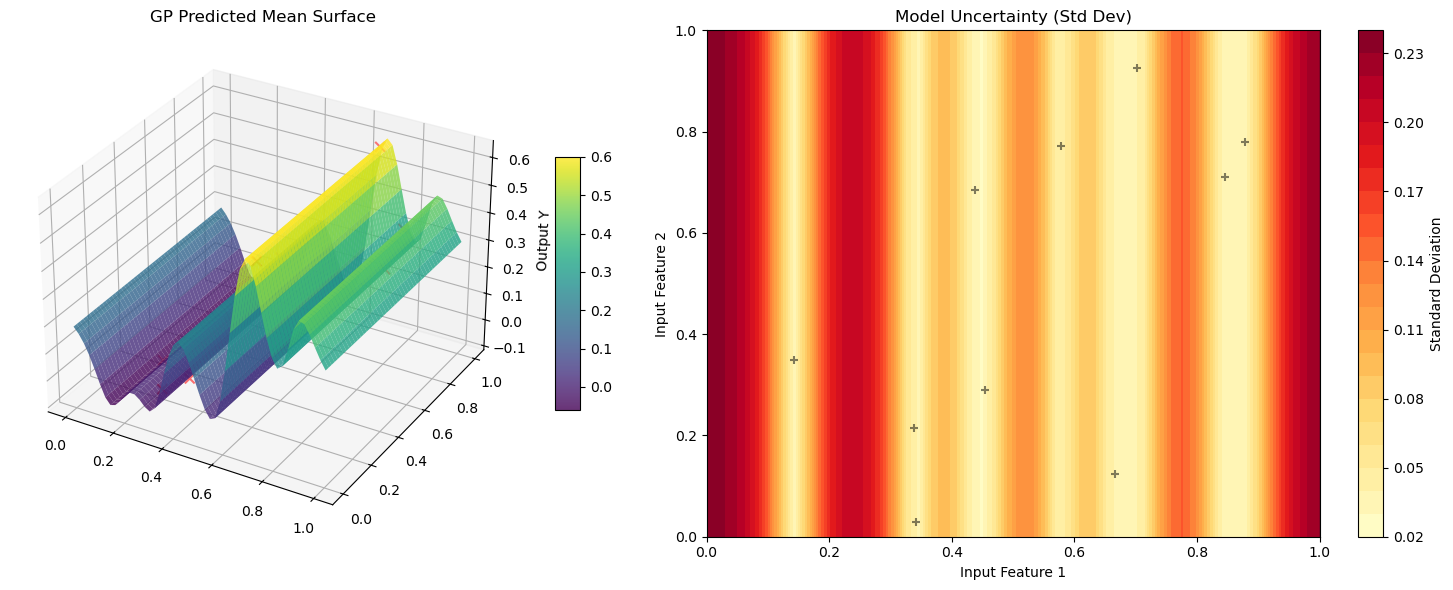

Data so far (sorted by descending observations): 
1: (x, f(x)) = ('0.67, 0.12', '5.3900e-01')
2: (x, f(x)) = ('0.88, 0.78', '4.2059e-01')
3: (x, f(x)) = ('0.14, 0.35', '-6.5624e-02')
4: (x, f(x)) = ('0.85, 0.71', '2.9399e-01')
5: (x, f(x)) = ('0.45, 0.29', '2.1496e-01')
6: (x, f(x)) = ('0.58, 0.77', '2.3106e-02')
7: (x, f(x)) = ('0.44, 0.69', '2.4462e-01')
8: (x, f(x)) = ('0.34, 0.03', '3.8749e-02')
9: (x, f(x)) = ('0.34, 0.21', '-1.3858e-02')
10: (x, f(x)) = ('0.70, 0.93', '6.1121e-01')
The GP predicts the value at [0.6939, 0.6122] will be 0.6096


In [14]:
AcquisitionFunctionBeta = 1.96
max_obs = -1

# create empty grid to feed in to the model
x1_linspace = np.linspace(0, 1, 50)
x2_linspace = np.linspace(0, 1, 50)
X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

#Number of queries in the optimisation loop
num_queries = 1
for i in range(0, num_queries):
    #Clear the outputs to keep the interface clean
    clear_output(wait = True)
    #  model = GaussianProcessRegressor(kernel=Matern_kernel, alpha=0, normalize_y=True, n_restarts_optimizer=20)
    # if i != 0:
    #     Fit the model
    #     model.fit(X,Y)
    #Calculate the mean and standard deviation and make them one-dimensional for plotting
    post_mean, post_std = model.predict(x_grid, return_std=True)
    print("Prediction done")

    plot3Dprediction2(X,Y, post_mean, post_std, X1_grid, X2_grid)
    # plot3Dprediction(X,Y,model)
    
    # DISPLAY OF X AND Y
    #Select a display format for X and Y
    X_format =  ['%.2f' % query[0] + ', %.2f' % query[1] for query in X]  # Format for 2D points
    Y_format = ['%.4e' % obs for obs in Y] #Four sig figs
    data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    print('Data so far (sorted by descending observations): ')
    print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
    # _ = input('Human Input to continue')
    
    # Acquisition function (UCB)
    acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
    # Find the index of the maximum value in the acquisition function
    best_index = np.argmax(acquisition_function)
    
    # Get the corresponding x value from the grid
    x_next = x_grid[best_index]  # This will be a 2D point
    y_predicted = post_mean[best_index]
    
    print(f"The GP predicts the value at [{x_next[0]:.4f}, {x_next[1]:.4f}] will be {y_predicted:.4f}")

    # Append data
    X = np.vstack([X, x_next])  # Use np.vstack to add a new row to X
    Y = np.append(Y, y_predicted)  # Use np.append to add a new value to Y
    
    # Sort lists according to observation values
    sorted_indices = np.argsort(-Y)  # Negative for descending order
    X = X[sorted_indices]
    Y = Y[sorted_indices]
    max_obs = max(max_obs, y_predicted)

In [149]:
print(acquisition_function.shape)
print("np.argmax(acquisition_function)", np.argmax(acquisition_function))
print("x_next",x_next)
print(post_mean[:5])

(2500,)
np.argmax(acquisition_function) 2184
x_next [0.69387755 0.87755102]
[-3.60303076e-04 -3.57746793e-04 -3.37562385e-04 -2.23774303e-04
 -8.21367320e-07]


## RBF Kernel - IGNORE

In [186]:
# # ########  IGNORE THIS 
# X,Y = load_data()
# # define the kernel, initialise the GP model, train
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# rbf_lengthscale = 0.1
# noise_assumption = 1e-8
# # kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
# RBFkernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e5))
#                      # length_scale_bounds=(1e-2, 1e3)  = model searches for good value
# model = GaussianProcessRegressor(kernel = RBFkernel, alpha=noise_assumption, n_restarts_optimizer=25)
#                      # n_restarts_optimizer runs the optimization 10 times
# model.fit(X, Y)
# print(f"Optimized Kernel: {model.kernel_}")

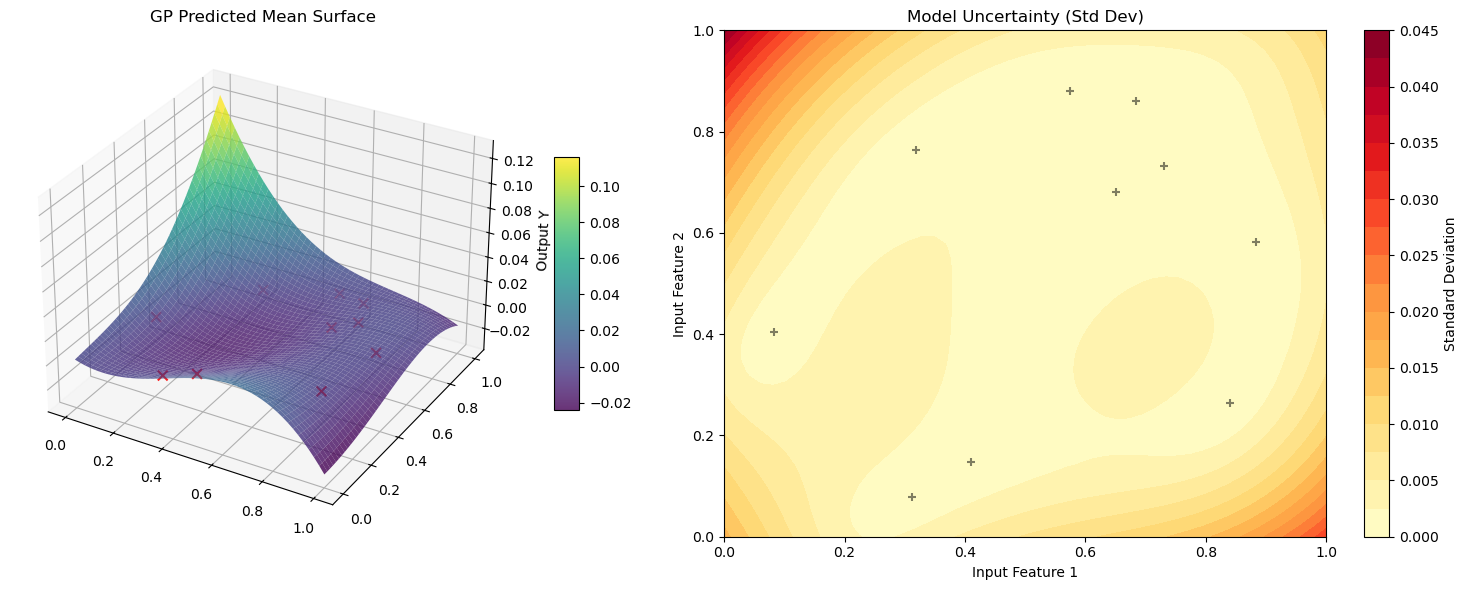

TypeError: only length-1 arrays can be converted to Python scalars

In [61]:
# AcquisitionFunctionBeta = 1.96
# max_obs = -1

# # create empty grid to feed in to the model
# x1_linspace = np.linspace(0, 1, 50)
# x2_linspace = np.linspace(0, 1, 50)
# X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
# # Flatten the grid to feed into the model
# x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

# #Number of queries in the optimisation loop
# num_queries = 1

# for i in range(0, num_queries):
#     clear_output(wait = True)
#     # model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
#     # model = GaussianProcessRegressor(kernel=RBFkernel,alpha=0, normalize_y=True, n_restarts_optimizer=20)
#     #Fit the model
#     # model.fit(X,Y)
#     #Calculate the mean and standard deviation and make them one-dimensional for plotting
#     post_mean, post_std = model.predict(x_grid, return_std=True)
#     # post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
    
#     #Initialise plots
#     plot3Dprediction2(X,Y,model)
    
#     # DISPLAY OF X AND Y
#     #Select a display format for X and Y
#     X_format = ['%.2f' % query for query in X] #Two sig figs
#     Y_format = ['%.4f' % obs for obs in Y] #Four sig figs
#     data = [(query, obs) for query, obs in zip(X_format, Y_format)]
#     print('Data so far (sorted by descending observations): ')
#     print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
#     #Initialise x
#     x = -1
#     # _ = input('Input anything to see the next chosen point') #You are using this to allow the user to change plots
    
#     acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
#     grid = x_grid.squeeze()
#     x = grid[np.argmax(acquisition_function)]         #  use the acquisition function
#     print("argmax from acquisition_function =",x)

#     best_index = np.argmax(acquisition_function)
#     x_next = grid[best_index]
#     y_predicted = post_mean[best_index]   
#     print(f"The GP predicts the value at {x_next:.4f} will be {y_predicted:.4f}")

#     #Append data, calculate function and sort lists according to observation values
#     X.append(x)
#     y = y_predicted
#     Y.append(y)
#     X = [x for _, x in sorted(zip(Y, X), reverse = True)]
#     Y.sort(reverse = True)
#     max_obs = max(max_obs, y)


## Misc

In [5]:
folder1 = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_2')
file_path_inputs = folder1 / folder2 / "initial_inputs.npy"
print(file_path_inputs)

C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data\function_2\initial_inputs.npy


In [103]:
num = 1

for i in range(0, num):
    print("count")

count
